# Molecular Solubility Prediction using PyCaret

## Overview
This notebook demonstrates the application of automated machine learning workflows using PyCaret for molecular solubility prediction.

The project focuses on:
- Molecular descriptor analysis
- Data preprocessing
- Automated regression model comparison
- Model evaluation and performance analysis

PyCaret was utilized to simplify model experimentation and accelerate predictive modeling for cheminformatics applications.

## Objectives
The objective is to evaluate multiple regression algorithms and identify models capable of accurately predicting aqueous molecular solubility (`LogS`) from molecular descriptor features.

## Tools and Libraries
- Python
- PyCaret
- Pandas
- NumPy
- Scikit-learn
- RDKit
- Matplotlib
- Seaborn

## Acknowledgment
Initial workflow inspired by educational resources from Data Professor and cheminformatics research literature.

## **1. Install PyCaret**

In [2]:
! pip install pycaret

## Load Dataset into Pandas

In [3]:
import pandas as pd

In [4]:
delaney_with_descriptors_url = 'https://raw.githubusercontent.com/dataprofessor/data/master/delaney_solubility_with_descriptors.csv'
dataset = pd.read_csv(delaney_with_descriptors_url)

In [5]:
dataset

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.59540,167.850,0.0,0.000000,-2.180
1,2.37650,133.405,0.0,0.000000,-2.000
2,2.59380,167.850,1.0,0.000000,-1.740
3,2.02890,133.405,1.0,0.000000,-1.480
4,2.91890,187.375,1.0,0.000000,-3.040
...,...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000,1.144
1140,3.42130,286.114,2.0,0.333333,-4.925
1141,3.60960,308.333,4.0,0.695652,-3.893
1142,2.56214,354.815,3.0,0.521739,-3.790


## Regression Model Development

### Model Configuration and Setup

In [6]:
!pip install pycaret --upgrade -q

# Patch directly via file path
import re

filepath = "/usr/local/lib/python3.12/dist-packages/pycaret/__init__.py"

with open(filepath, 'r') as f:
    content = f.read()

content = content.replace(
    'elif sys.version_info >= (3, 12):',
    'elif sys.version_info >= (3, 99):'
)

with open(filepath, 'w') as f:
    f.write(content)

print("Patched successfully!")

Patched successfully!


In [7]:
from pycaret.regression import *

In [8]:
model = setup(data = dataset, target = 'logS', train_size=0.8)

,Description,Value
0,Session id,7535
1,Target,logS
2,Target type,Regression
3,Original data shape,"(1144, 5)"
4,Transformed data shape,"(1144, 5)"
5,Transformed train set shape,"(915, 5)"
6,Transformed test set shape,"(229, 5)"
7,Numeric features,4
8,Preprocess,True
9,Imputation type,simple


### Regression Model Comparison

The training subset (80% of the dataset) was used for regression model training and comparative performance evaluation.

In [9]:
compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.5341,0.5546,0.7421,0.8737,0.2077,0.5023,0.2060
rf,Random Forest Regressor,0.5441,0.5737,0.7544,0.8690,0.2108,0.4987,0.3200
gbr,Gradient Boosting Regressor,0.5848,0.6115,0.7798,0.8607,0.2231,0.5335,0.1200
lightgbm,Light Gradient Boosting Machine,0.5758,0.6168,0.7832,0.8596,0.2200,0.5164,0.4840
xgboost,Extreme Gradient Boosting,0.5821,0.6462,0.8003,0.8523,0.2239,0.5317,0.0880
ada,AdaBoost Regressor,0.7106,0.8356,0.9087,0.8104,0.2463,0.6602,0.0850
dt,Decision Tree Regressor,0.7048,0.9697,0.9820,0.7794,0.2580,0.6044,0.0190
br,Bayesian Ridge,0.7752,1.0364,1.0135,0.7636,0.2891,0.8145,0.0170
lar,Least Angle Regression,0.7747,1.0364,1.0135,0.7636,0.2892,0.8136,0.0180
ridge,Ridge Regression,0.7748,1.0364,1.0135,0.7636,0.2892,0.8138,0.0350


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

ExtraTreesRegressor(n_jobs=-1, random_state=7535)

### Regression Model Training

In [10]:
et = create_model('et')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.5231,0.5897,0.7679,0.8638,0.2022,0.2443
1,0.6163,0.6734,0.8206,0.8463,0.2567,1.3273
2,0.6096,0.7094,0.8422,0.8007,0.2403,0.4279
3,0.5404,0.5468,0.7395,0.8851,0.2061,0.4657
4,0.4827,0.4238,0.6510,0.9231,0.2052,0.6902
5,0.4372,0.4220,0.6496,0.8923,0.1628,0.2655
6,0.5667,0.5801,0.7617,0.8877,0.2079,0.2889
7,0.5175,0.5087,0.7132,0.8671,0.2151,0.4243
8,0.5491,0.6053,0.7780,0.8816,0.1914,0.5838


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

### Hyperparameter Optimization

Model hyperparameters were optimized using iterative tuning procedures to improve predictive performance. Mean Absolute Error (MAE) was used as the primary evaluation metric during optimization.

In [11]:
tuned_et = tune_model(et, n_iter=50, optimize='mae')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.5558,0.5628,0.7502,0.8700,0.1922,0.2635
1,0.6088,0.6169,0.7854,0.8592,0.2524,1.2783
2,0.6321,0.7397,0.8601,0.7922,0.2356,0.3892
3,0.5277,0.5265,0.7256,0.8894,0.2182,0.5647
4,0.6041,0.5520,0.7430,0.8998,0.2311,0.5528
5,0.4641,0.4536,0.6735,0.8842,0.1770,0.2904
6,0.5731,0.5328,0.7299,0.8969,0.2113,0.2965
7,0.5527,0.4665,0.6830,0.8781,0.2153,0.4776
8,0.5984,0.6908,0.8312,0.8649,0.2205,0.7720


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 50 candidates, totalling 500 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [12]:
print(tuned_et)

ExtraTreesRegressor(n_jobs=-1, random_state=7535)


## Model Performance Analysis

### Regression Performance Visualization
Regression performance plots were generated to evaluate predictive accuracy and model behavior across the training and testing datasets.

### Residual Error Analysis

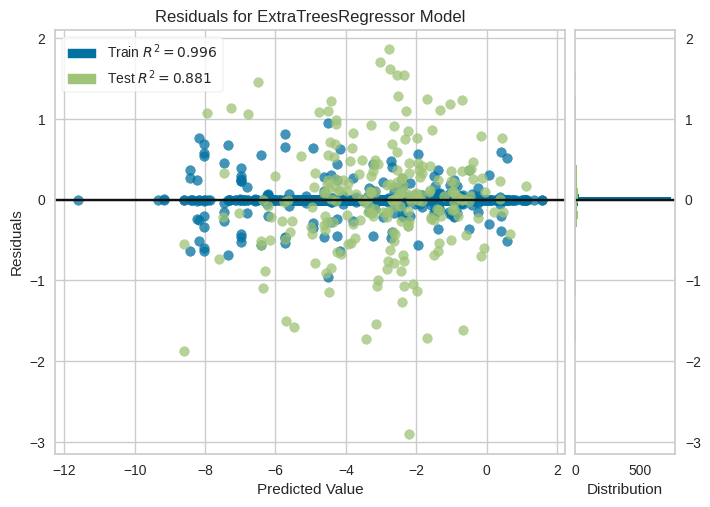

In [13]:
plot_model(et, 'residuals')

### Prediction Error Analysis

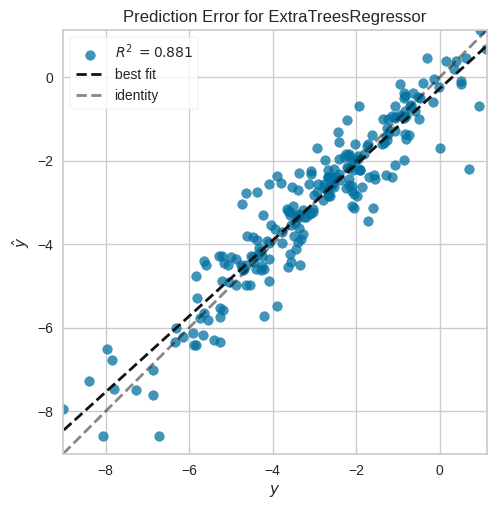

In [14]:
plot_model(et, 'error')

### Cook’s Distance Analysis

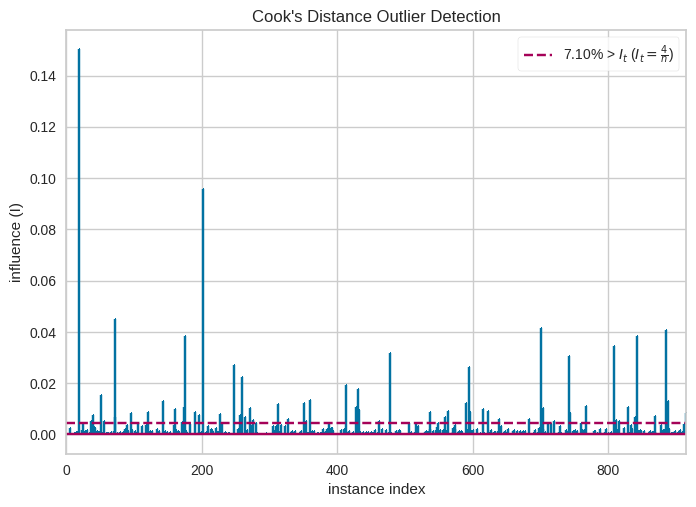

In [15]:
plot_model(et, 'cooks')

### Recursive Feature Selection Analysis

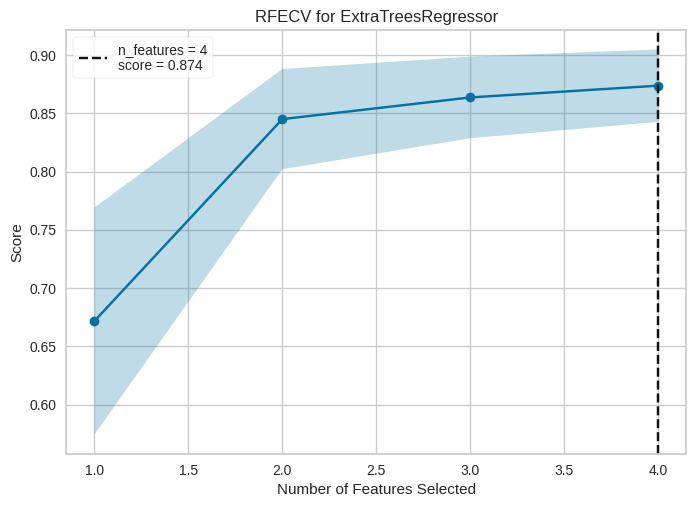

In [16]:
plot_model(et, 'rfe')

### Learning Curve Analysis

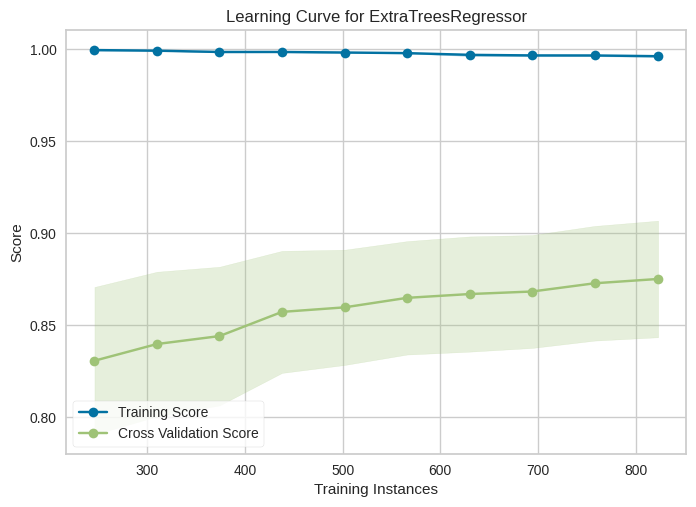

In [17]:
plot_model(et, 'learning')

### Validation Curve Analysis

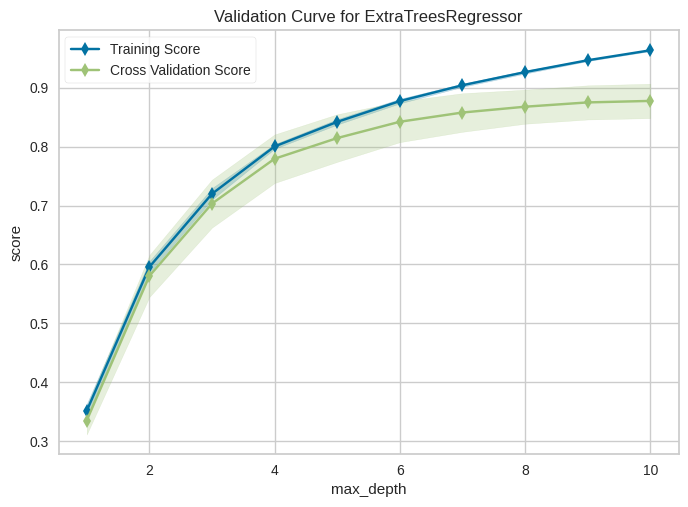

In [18]:
plot_model(et, 'vc')

### Manifold Learning Visualization

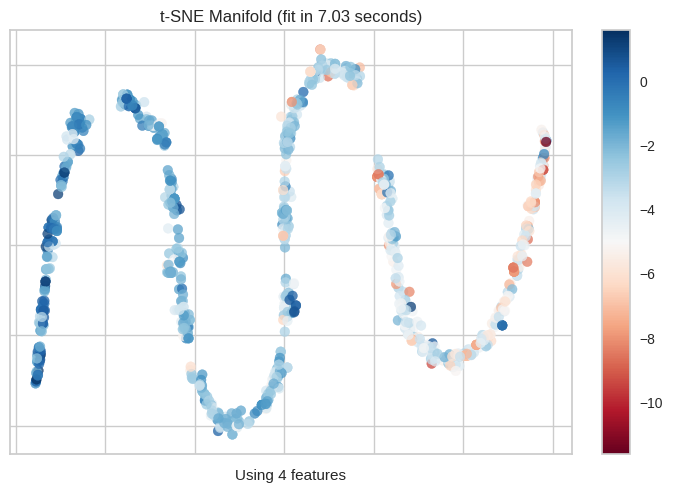

In [19]:
plot_model(et, 'manifold')

### Feature Importance Analysis

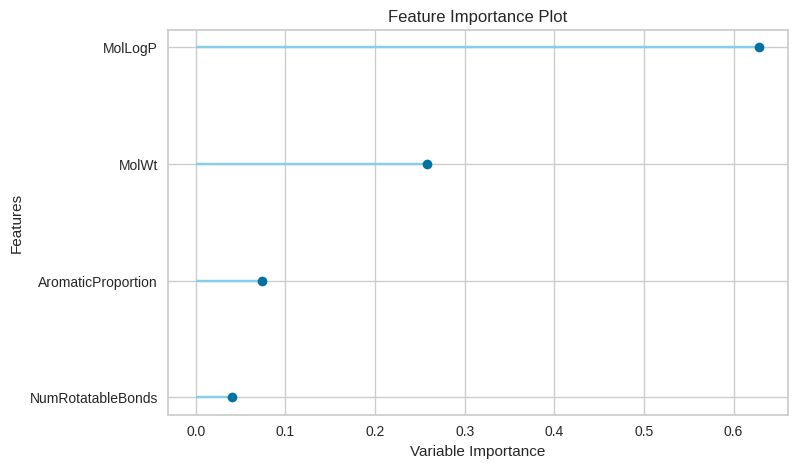

In [20]:
plot_model(et, 'feature')

### Model Hyperparameter Analysis

The optimized model hyperparameters were examined to evaluate the configuration contributing to predictive performance.

In [21]:
plot_model(et, 'parameter')

,Parameters
bootstrap,False
ccp_alpha,0.0
criterion,squared_error
max_depth,None
max_features,1.0
max_leaf_nodes,None
max_samples,None
min_impurity_decrease,0.0
min_samples_leaf,1
min_samples_split,2


The optimized hyperparameter configuration of the tuned regression model is presented below.

In [22]:
plot_model(tuned_et, 'parameter')

,Parameters
bootstrap,False
ccp_alpha,0.0
criterion,squared_error
max_depth,None
max_features,1.0
max_leaf_nodes,None
max_samples,None
min_impurity_decrease,0.0
min_samples_leaf,1
min_samples_split,2


### Comprehensive Model Evaluation

All available regression evaluation visualizations were generated to assess overall model performance and predictive behavior.

In [23]:
evaluate_model(tuned_et)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

## Model Interpretation using SHAP
SHAP (SHapley Additive exPlanations) analysis was used to interpret feature contributions and improve model explainability.

The visualization highlights the influence of molecular descriptors on solubility prediction outcomes.

### SHAP Summary Visualization

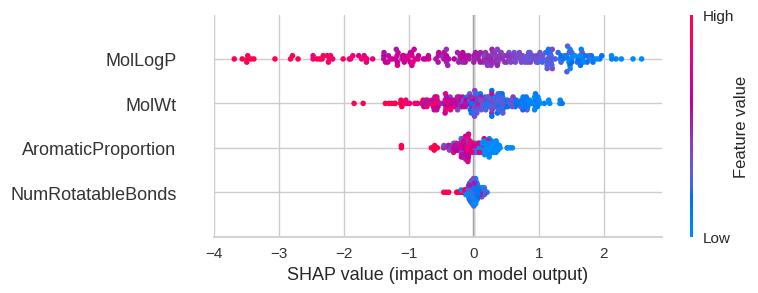

In [24]:
interpret_model(et)

### Feature Correlation Analysis

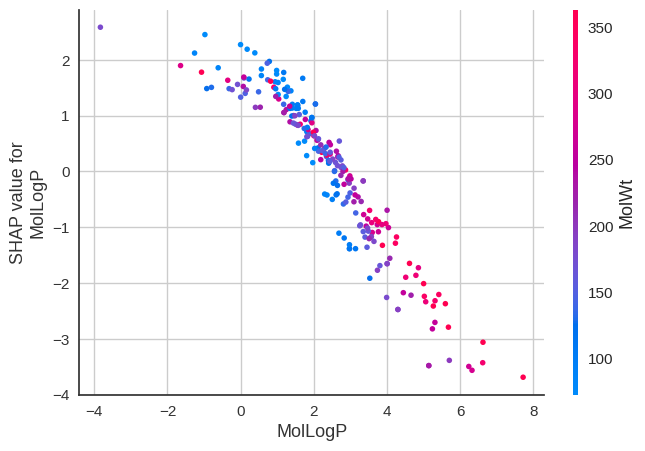

In [25]:
interpret_model(et, plot = 'correlation')

### SHAP Force Plot Analysis

The SHAP force plot was used to visualize the contribution of individual molecular descriptors to specific prediction outcomes.

The plot illustrates how features positively or negatively influence the predicted solubility values.

In [26]:
interpret_model(et, plot = 'reason', observation = 10)

## External Model Evaluation

The trained regression model was evaluated on the independent test dataset to assess predictive generalization on previously unseen data.

In [27]:
prediction_holdout = predict_model(et)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.4755,0.4444,0.6666,0.8812,0.1862,1.1786


In [28]:
prediction_holdout.head()

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS,prediction_label
105,6.24020,270.501007,16.0,0.000000,-8.400,-7.26579
523,4.26300,342.778015,4.0,0.666667,-5.839,-4.75222
952,1.17890,108.139999,1.0,0.750000,-0.400,-0.13210
973,1.30040,139.110001,1.0,0.600000,-0.740,-1.37500
187,1.81142,182.134995,2.0,0.461538,-3.000,-2.82000


---